In [5]:
from dotenv import load_dotenv
from pathlib import Path
import sys
import os

# Walk up until we find the project root (folder with the .env)
current_path = Path().resolve()
for parent in [current_path] + list(current_path.parents):
    if (parent / ".env").exists():
        load_dotenv(parent / ".env")
        project_root = os.getenv("PROJECT_ROOT")
        print(project_root)
        sys.path.append(project_root)     
        break


%load_ext autoreload
%autoreload 2

/mnt/home/test/beluga-call-pipeline/


In [ ]:
# import librosa
# import noisereduce as nr
# import soundfile as fs 

# audio, sr = librosa.load("../data/evaluation_snippets/v2/KAM_2020/Boat/5725.200801152155.snippet.wav", sr=None)
# audio_denoised = nr.reduce_noise(y=audio, sr=sr, stationary=False)

# fs.write("../data/evaluation_snippets/v2/KAM_2020/Boat/5725.200801152155.snippet_denoised.wav", audio_denoised, sr)

In [6]:
from data_preprocessing.spectrogram.spectrogram_generator import SpectrogramGenerator

spect_generator = SpectrogramGenerator(
        n_fft=2048,
        hop_length=int(2048/2),
        n_mels=64,
        fmin=200,
        sample_rate=192000, 
    )

In [7]:
spect_generator.sample_rate

192000

In [15]:
import pandas as pd
pd.set_option('display.max_columns', None)
import librosa
import noisereduce as nr
import soundfile as fs 


labels_df = pd.read_csv("../data/Verified_Dataset/labels/labels_merged.csv")
files_to_check = ["5725.200726191905.snippet.wav"]

audios = []
audios_denoised = []


for file in files_to_check:
    sample = labels_df[labels_df["labeled_snippet_filename"] == file]
    snippet_dir = sample.iloc[0]["labeled_snippet_dir"]
    snippet_fp = snippet_dir.replace("../../", "../") + "/" + file

    audio, sr, original_sr = spect_generator.load_audio(snippet_fp)
    audio_denoised = nr.reduce_noise(y=audio, sr=sr, stationary=False, time_constant_s=10, prop_decrease=0.5)
    audios.append(audio)
    audios_denoised.append(audio_denoised)
   
    print(sample)

labels_df

                   clip_filename  ECHO  BBPC  HFPC  Whistle  Call  Boat  \
11905  KAM_20200726_19190500.wav     1     0     0        0     1   1.0   
11906  KAM_20200726_19190600.wav     1     0     0        0     1   1.0   
11907  KAM_20200726_19190700.wav     1     0     0        0     1   1.0   
11908  KAM_20200726_19190800.wav     1     0     0        0     1   1.0   
11909  KAM_20200726_19190900.wav     1     0     0        0     1   1.0   
...                          ...   ...   ...   ...      ...   ...   ...   
12254  KAM_20200726_19245400.wav     1     0     0        0     1   1.0   
12255  KAM_20200726_19245500.wav     1     0     0        0     1   1.0   
12256  KAM_20200726_19245600.wav     1     0     0        0     1   1.0   
12257  KAM_20200726_19245700.wav     1     0     0        0     1   1.0   
12258  KAM_20200726_19245800.wav     1     0     0        0     1   1.0   

      labeling_effort DETAIL  Begin Time (s)  End Time (s) GROUNDTRUTH Notes  \
11905   evaluation_

,clip_filename,ECHO,BBPC,HFPC,Whistle,Call,Boat,labeling_effort,DETAIL,Begin Time (s),End Time (s),GROUNDTRUTH,Notes,original_filename,labeled_snippet_filename,snippet_start_time,snippet_start_s,snippet_end_s,Site,labeled_snippet_dir,HydrophoneModel,HydrophoneSensitivity,clip_start_time,clip_end_time,DETAILS,boat_labeling_file,boat_labeling_file_id,annotator,SnippetFilename,start_s,end_s
0,BSM_20170724_09471700.wav,0,0,0,0,0,1.0,evaluation_v2,NaN,0.0,1.0,a,NaN,201359382.170724093002.wav,201359382.170724094717.snippet.wav,2017-07-24 09:47:17,1035.0,1155.0,BSM,../../data/evaluation_snippets/v2/BSM_2017\Boat,201359382,-172.7,2017-07-24 09:47:17,2017-07-24 09:47:18,NaN,201359382.170724093002.Table.1.selections.txt,1.0,VA,NaN,NaN,NaN
1,BSM_20170724_09471800.wav,0,0,0,0,0,1.0,evaluation_v2,NaN,1.0,2.0,a,NaN,201359382.170724093002.wav,201359382.170724094717.snippet.wav,2017-07-24 09:47:17,1035.0,1155.0,BSM,../../data/evaluation_snippets/v2/BSM_2017\Boat,201359382,-172.7,2017-07-24 09:47:18,2017-07-24 09:47:19,NaN,201359382.170724093002.Table.1.selections.txt,1.0,VA,NaN,NaN,NaN
2,BSM_20170724_09471900.wav,0,0,0,0,0,1.0,evaluation_v2,NaN,2.0,3.0,a,NaN,201359382.170724093002.wav,201359382.170724094717.snippet.wav,2017-07-24 09:47:17,1035.0,1155.0,BSM,../../data/evaluation_snippets/v2/BSM_2017\Boat,201359382,-172.7,2017-07-24 09:47:19,2017-07-24 09:47:20,NaN,201359382.170724093002.Table.1.selections.txt,1.0,VA,NaN,NaN,NaN
3,BSM_20170724_09472000.wav,0,0,0,0,0,1.0,evaluation_v2,NaN,3.0,4.0,a,NaN,201359382.170724093002.wav,201359382.170724094717.snippet.wav,2017-07-24 09:47:17,1035.0,1155.0,BSM,../../data/evaluation_snippets/v2/BSM_2017\Boat,201359382,-172.7,2017-07-24 09:47:20,2017-07-24 09:47:21,NaN,201359382.170724093002.Table.1.selections.txt,1.0,VA,NaN,NaN,NaN
4,BSM_20170724_09472100.wav,0,0,0,0,0,1.0,evaluation_v2,NaN,4.0,5.0,a,NaN,201359382.170724093002.wav,201359382.170724094717.snippet.wav,2017-07-24 09:47:17,1035.0,1155.0,BSM,../../data/evaluation_snippets/v2/BSM_2017\Boat,201359382,-172.7,2017-07-24 09:47:21,2017-07-24 09:47:22,NaN,201359382.170724093002.Table.1.selections.txt,1.0,VA,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15513,RDL_20200906_14555938.wav,0,0,0,0,0,NaN,old_abs_from_3s_snippets,NaN,NaN,NaN,NaN,NaN,5675.200906144958.wav,NaN,2020-09-06 14:55:57.380000,NaN,NaN,RDL,NaN,5675,-176.5,2020-09-06 14:55:59.380000,2020-09-06 14:56:00.380000,NaN,NaN,NaN,NaN,RDL_20200906_14555738.wav,1.0,2.0
15514,RDL_20200906_14560038.wav,0,0,0,0,0,NaN,old_abs_from_3s_snippets,NaN,NaN,NaN,NaN,NaN,5675.200906144958.wav,NaN,2020-09-06 14:55:57.380000,NaN,NaN,RDL,NaN,5675,-176.5,2020-09-06 14:56:00.380000,2020-09-06 14:56:01.380000,NaN,NaN,NaN,NaN,RDL_20200906_14555738.wav,2.0,3.0
15515,RDL_20200906_14573769.wav,0,0,0,0,0,NaN,old_abs_from_3s_snippets,NaN,NaN,NaN,NaN,NaN,5675.200906144958.wav,NaN,2020-09-06 14:57:36.690000,NaN,NaN,RDL,NaN,5675,-176.5,2020-09-06 14:57:37.690000,2020-09-06 14:57:38.690000,NaN,NaN,NaN,NaN,RDL_20200906_14573669.wav,0.0,1.0
15516,RDL_20200906_14573869.wav,0,0,0,0,0,NaN,old_abs_from_3s_snippets,NaN,NaN,NaN,NaN,NaN,5675.200906144958.wav,NaN,2020-09-06 14:57:36.690000,NaN,NaN,RDL,NaN,5675,-176.5,2020-09-06 14:57:38.690000,2020-09-06 14:57:39.690000,NaN,NaN,NaN,NaN,RDL_20200906_14573669.wav,1.0,2.0


In [ ]:
audios_denoised[0] = nr.reduce_noise(y=audio[0], sr=sr, stationary=False, time_constant_s=10, prop_decrease=0.5)

15.0


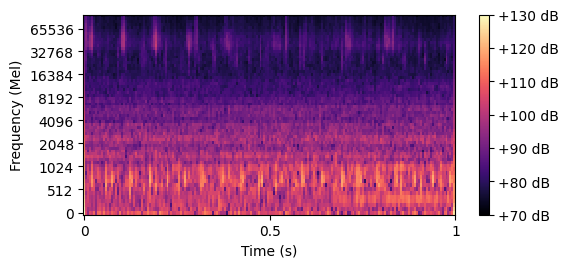

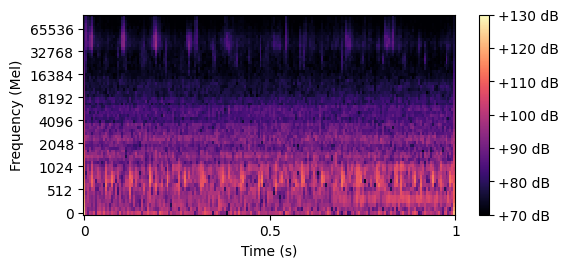

(67968000,)
(67968000,)
16.0


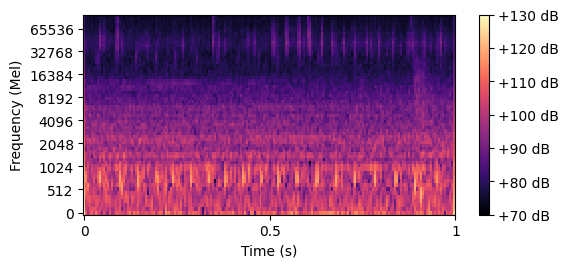

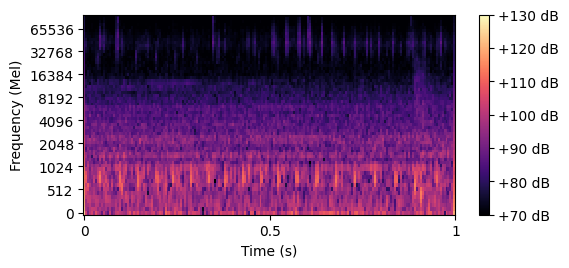

(67968000,)
(67968000,)
19.0


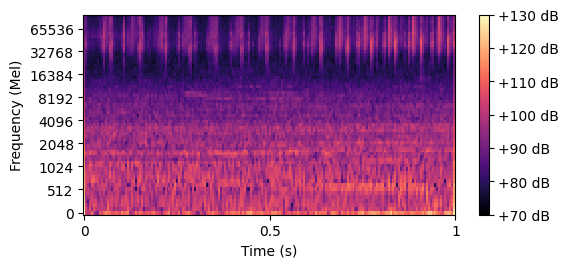

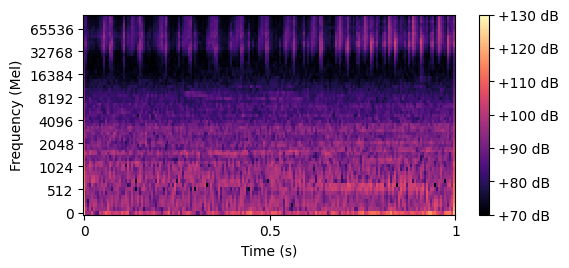

(67968000,)
(67968000,)
20.0


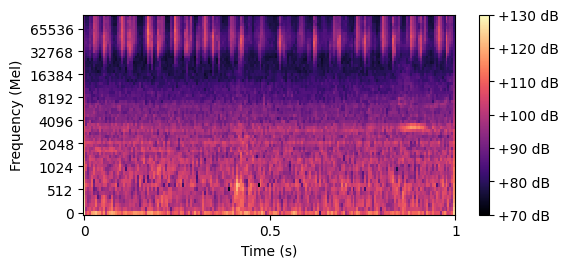

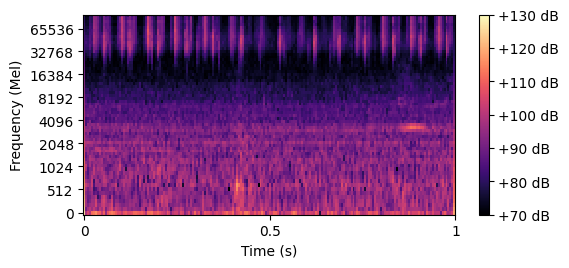

(67968000,)
(67968000,)
21.0


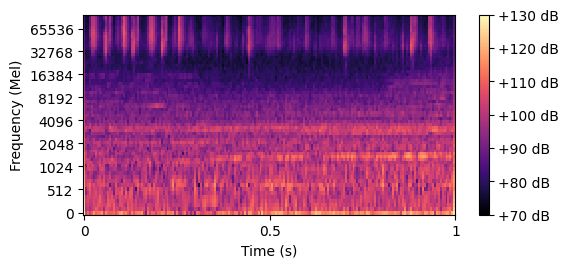

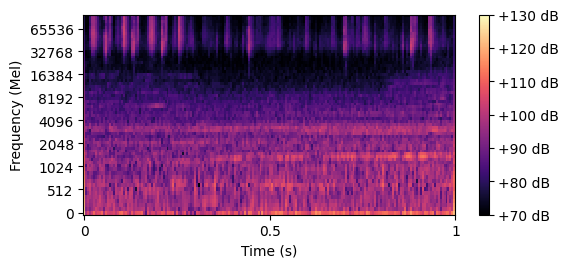

(67968000,)
(67968000,)
33.0


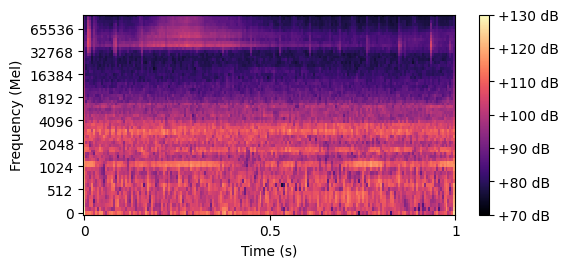

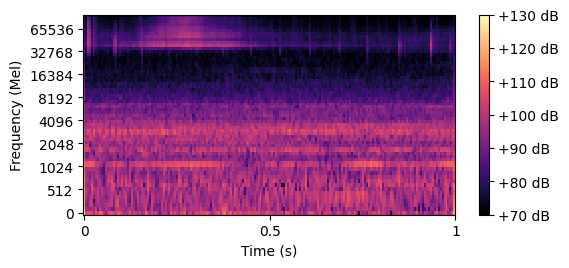

(67968000,)
(67968000,)
34.0


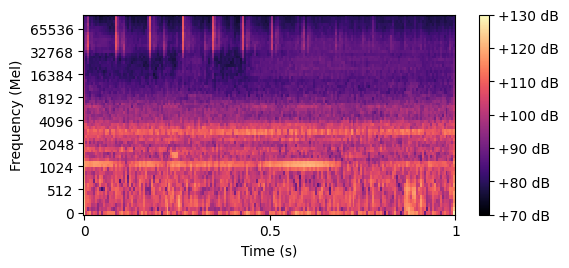

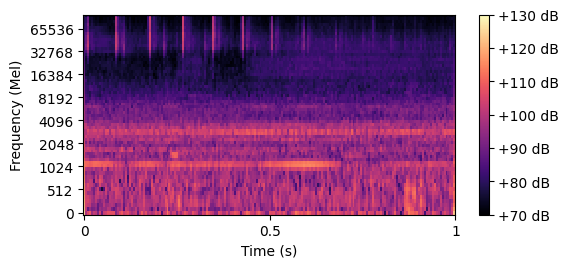

(67968000,)
(67968000,)
36.0


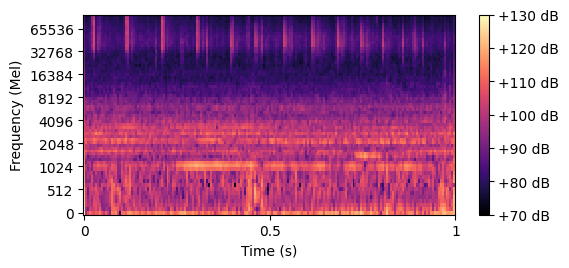

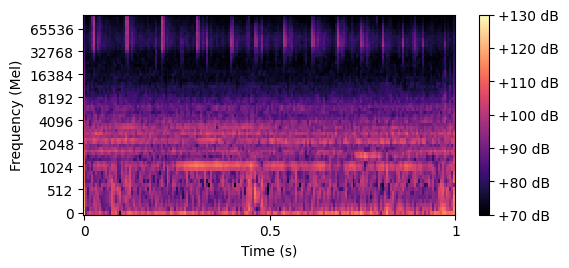

(67968000,)
(67968000,)
112.0


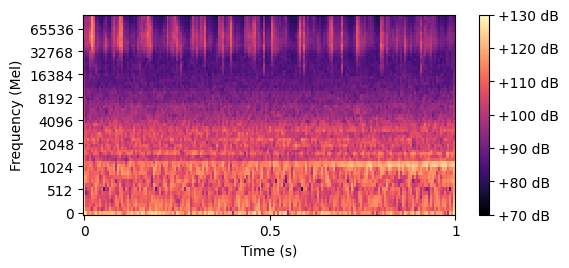

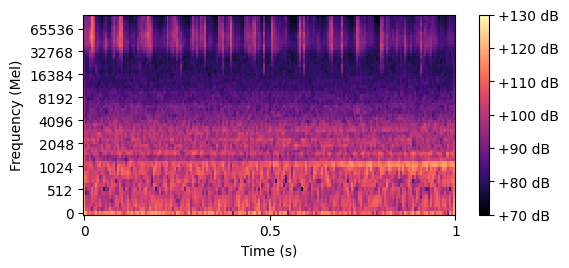

(67968000,)
(67968000,)
114.0


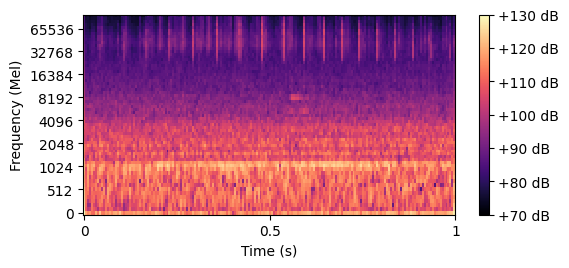

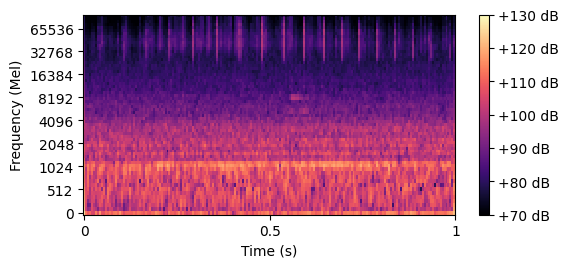

(67968000,)
(67968000,)
142.0


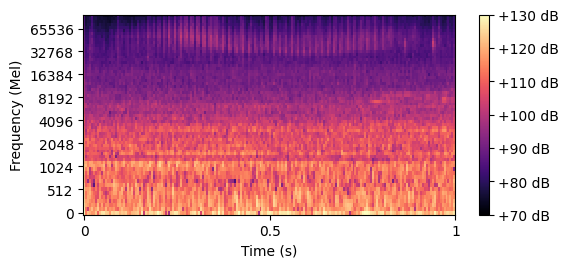

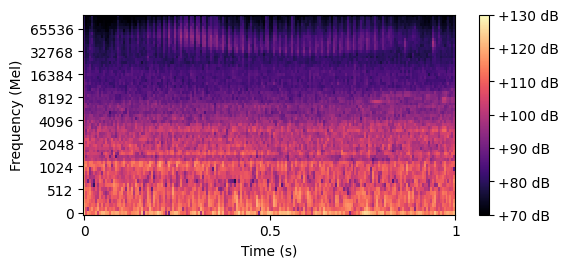

(67968000,)
(67968000,)
339.0


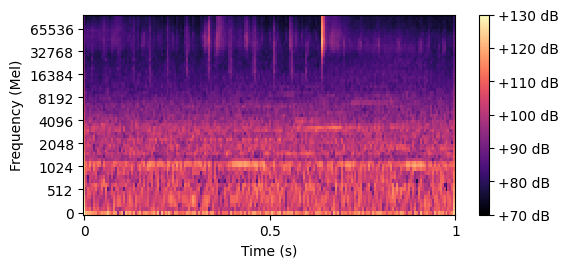

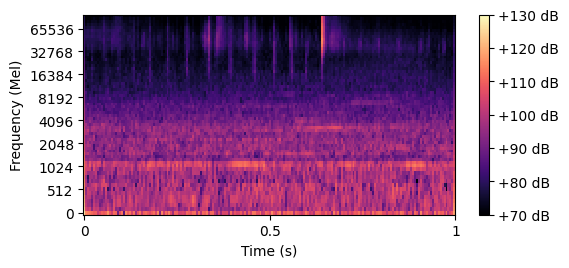

(67968000,)
(67968000,)
341.0


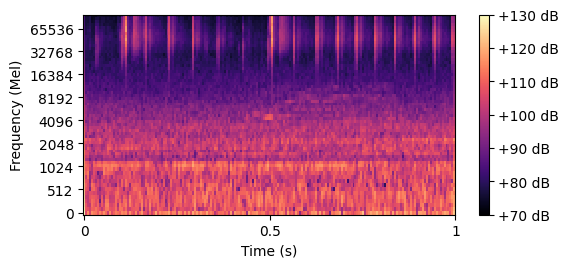

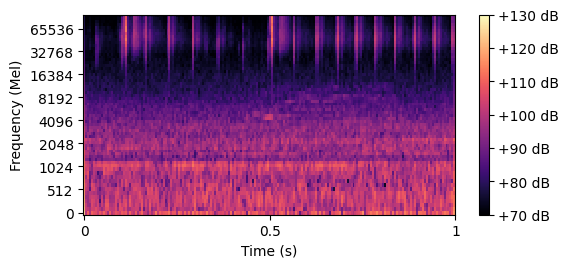

(67968000,)
(67968000,)
342.0


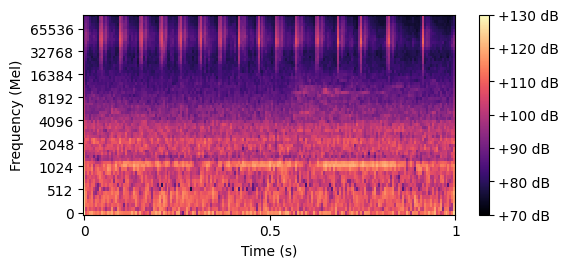

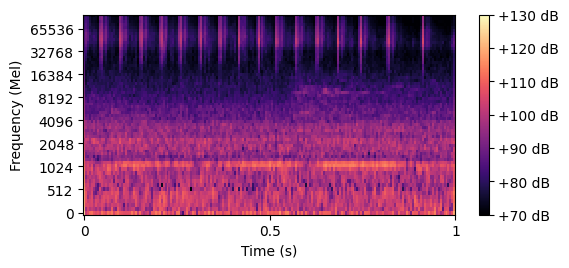

(67968000,)
(67968000,)
345.0


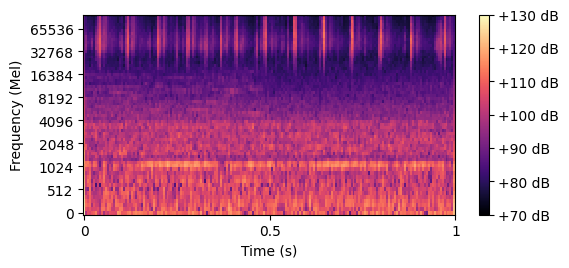

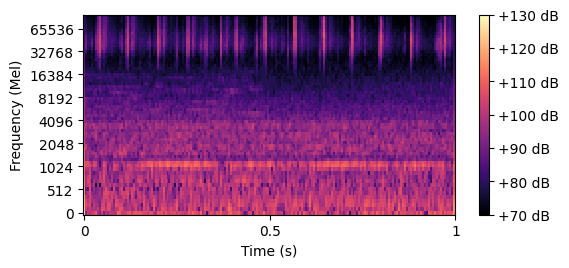

(67968000,)
(67968000,)


In [16]:
sr = spect_generator.sample_rate

for i in range(len(files_to_check)):
    file = files_to_check[i]
    audio = audios[i]
    audio_denoised = audios_denoised[i]
    

    file_df = labels_df[labels_df["labeled_snippet_filename"] == file]
    sample = file_df[file_df["Whistle"] == 1]

    for i, row in sample.iterrows():
        print(row["Begin Time (s)"])

        start_idx = int(row["Begin Time (s)"]*sr)
        end_idx = int((row["End Time (s)"])*sr)
        clip = audio[start_idx:end_idx]
        power_spect = spect_generator.compute_mel_power_spect(clip)
        dB_spect = spect_generator.power_to_db(power_spect, hydrophone_sensitivity=row["HydrophoneSensitivity"])
        spect_generator.plot_spect(dB_spect, figsize=(6,2.6), title="", tick_interval=0.5, colorbar_range=(70, 130), transparent_background=True)


        clip_denoised = audio_denoised[start_idx:end_idx]
        power_spect = spect_generator.compute_mel_power_spect(clip_denoised)
        dB_spect = spect_generator.power_to_db(power_spect, hydrophone_sensitivity=row["HydrophoneSensitivity"])
        spect_generator.plot_spect(dB_spect, figsize=(6,2.6), title="", tick_interval=0.5, colorbar_range=(70, 130), transparent_background=True)

        print(audio.shape)
        print(audio_denoised.shape)
        # break
